In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler,StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

In [4]:

data1=pd.read_excel("data/data_Ra_Density_my_model.xlsx")
data1=data1.dropna()
data1.columns=['p','v','h','t','Ra','density']
data1=data1.loc[:86]
data1['ved']=(data1['p']*1000*1000)/(data1['v'] * data1['t']  *data1['h'])
data1['ped']=(data1['p'])/(data1['v'] )
data1['led']=(data1['p']*1000)/(data1['v'] * data1['h'])

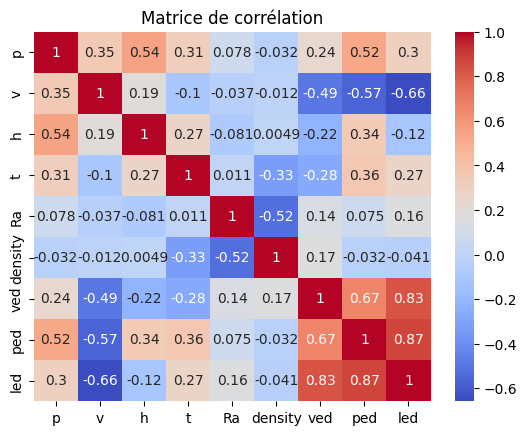

In [5]:

sns.heatmap(data1.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


In [6]:
X=data1[['p','v','h', 't', 'ved', 'ped', 'led']]
y=data1[['Ra','density']]

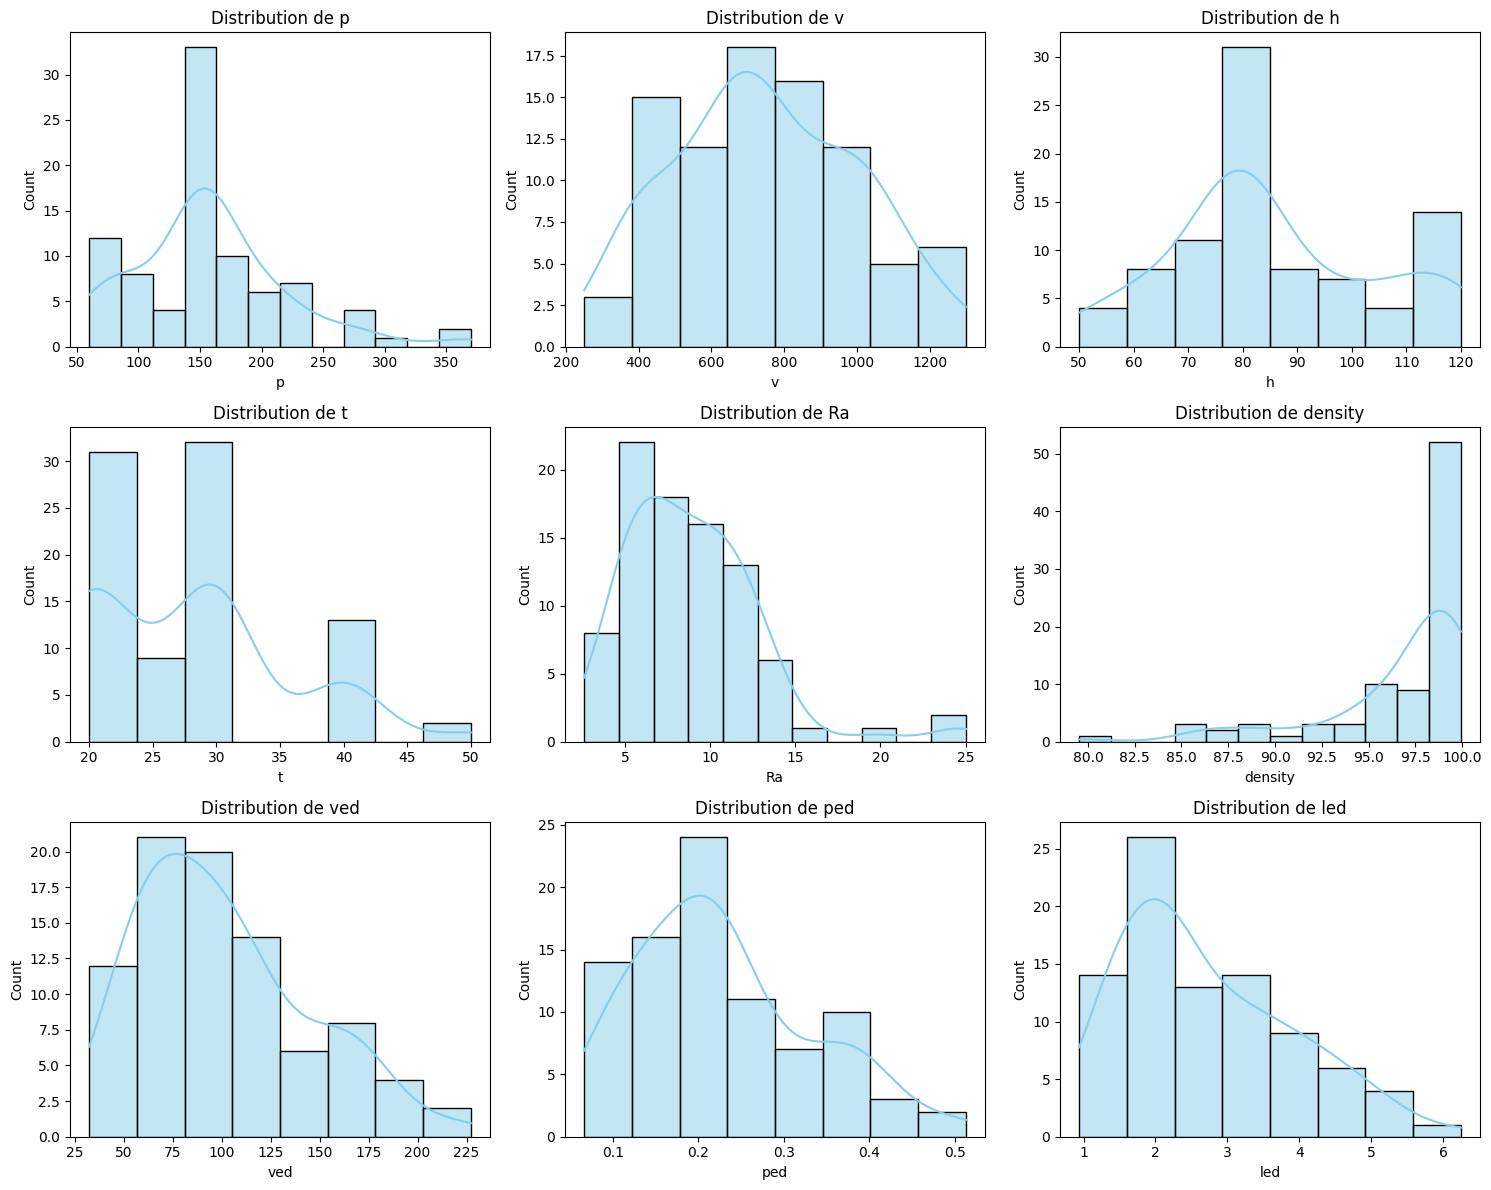

In [7]:

variables = ['p', 'v', 'h', 't', 'Ra', 'density', 'ved', 'ped', 'led']


n_cols = 3
n_rows = (len(variables) + n_cols - 1) // n_cols


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

for i, var in enumerate(variables):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] if n_rows > 1 else axes[col]
    sns.histplot(data1[var], kde=True, ax=ax, color="skyblue")
    ax.set_title(f"Distribution de {var}")
    ax.set_xlabel(var)


for j in range(len(variables), n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

In [8]:


Ra = y['Ra'].values.flatten()
density = y['density'].values.flatten()


scaler_X = RobustScaler()
X_scaled = scaler_X.fit_transform(X[['p', 'v', 'h', 't']])


Ra_shifted = Ra + 1e-5  
Ra_boxcox, lambda_ra = boxcox(Ra_shifted)
scaler_Ra = RobustScaler()
Ra_scaled = scaler_Ra.fit_transform(Ra_boxcox.reshape(-1, 1))


scaler_density = RobustScaler()
density_scaled = scaler_density.fit_transform(density.reshape(-1, 1))


y_scaled = np.hstack([Ra_scaled, density_scaled])


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=True)


In [9]:
def inverse_transform(pred_scaled, lambda_ra, scaler_ra, scaler_dens):
    ra_inv = scaler_ra.inverse_transform(pred_scaled[:, 0].reshape(-1, 1))
    ra_orig = np.exp(np.log(ra_inv * lambda_ra + 1) / lambda_ra) - 1e-5

    dens_inv = scaler_dens.inverse_transform(pred_scaled[:, 1].reshape(-1, 1))
    return ra_orig.flatten(), dens_inv.flatten()

In [10]:
def print_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"—— Résultats pour {name} ——")
    print(f"R²    : {r2:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print()

In [12]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 5000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }
    
    rf = MultiOutputRegressor(RandomForestRegressor(random_state=42, **params))
    score = cross_val_score(rf, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

best_rf = RandomForestRegressor(random_state=42, **study.best_params)
multi_rf = MultiOutputRegressor(best_rf).fit(X_train, y_train)


y_pred = multi_rf.predict(X_test)

y_pred_ra, y_pred_density = inverse_transform(y_pred, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")



[I 2025-06-24 09:23:10,918] A new study created in memory with name: no-name-07228ca0-74c2-4228-84d2-a7f2a5e002f0
[I 2025-06-24 09:23:16,854] Trial 0 finished with value: 0.1505306565527833 and parameters: {'n_estimators': 1895, 'max_depth': 8, 'min_samples_split': 12, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.1505306565527833.
[I 2025-06-24 09:23:23,893] Trial 1 finished with value: 0.10865592751387516 and parameters: {'n_estimators': 2691, 'max_depth': 11, 'min_samples_split': 19, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.1505306565527833.
[I 2025-06-24 09:23:27,722] Trial 2 finished with value: 0.09084219149563012 and parameters: {'n_estimators': 916, 'max_depth': 21, 'min_samples_split': 26, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.1505306565527833.
[I 2025-06-24 09:23:34,843] Trial 3 finished with value: 0.12572480298171188 and parameters: {'n_estimators': 2811, 'max_depth': 29, 'min_samples_split': 25, 'min_samples_leaf': 4}. Best is trial 0 w

—— Résultats pour Ra ——
R²    : 0.2221
MAE   : 1.7011
RMSE  : 2.3826
MAPE  : 15.81%

—— Résultats pour Density ——
R²    : 0.1765
MAE   : 2.1031
RMSE  : 4.5131
MAPE  : 2.44%



In [13]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV


param_grid = {
    "estimator__C": [1, 10,100],
    "estimator__epsilon": [ 0.01, 0.1, 0.5, 1.0],
    "estimator__kernel": ['rbf', 'sigmoid','poly'],
    "estimator__degree": [2, 3, 4],
    "estimator__gamma": ['scale', 'auto']
}


base_svr = SVR()
multi_svr = MultiOutputRegressor(base_svr)


grid_search = GridSearchCV(
    multi_svr,
    param_grid,
    cv=3,
    scoring='r2',
    verbose=0,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model_svr = grid_search.best_estimator_
y_pred = best_model_svr.predict(X_test)

y_pred_ra, y_pred_density = inverse_transform(y_pred, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")

print("\n🔍 Best hyperparameters found:")
print(grid_search.best_params_)


—— Résultats pour Ra ——
R²    : 0.0815
MAE   : 1.6111
RMSE  : 2.5890
MAPE  : 14.28%

—— Résultats pour Density ——
R²    : 0.4434
MAE   : 1.9505
RMSE  : 3.7105
MAPE  : 2.23%


🔍 Best hyperparameters found:
{'estimator__C': 10, 'estimator__degree': 2, 'estimator__epsilon': 0.01, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}


In [15]:
import optuna
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor



def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 5000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
    }

    model = MultiOutputRegressor(XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return mean_squared_error(y_test, y_pred)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300) 

best_params = study.best_params
best_model_xgb = MultiOutputRegressor(XGBRegressor(**best_params, random_state=42, n_jobs=-1))
best_model_xgb.fit(X_train, y_train)
y_pred_scaled = best_model_xgb.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_scaled, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)



print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")

print("\n✅ Best XGBoost parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")


[I 2025-06-24 09:39:59,379] A new study created in memory with name: no-name-45d9874c-e847-4dad-b899-33dd0609cba6
[I 2025-06-24 09:40:00,505] Trial 0 finished with value: 0.9365908383987827 and parameters: {'n_estimators': 3600, 'max_depth': 9, 'learning_rate': 0.008001682647563499, 'subsample': 0.8377586789640716, 'colsample_bytree': 0.620072066171869, 'gamma': 1.7234366942415147, 'reg_alpha': 0.9525610659285112, 'reg_lambda': 0.003629343343455882}. Best is trial 0 with value: 0.9365908383987827.
[I 2025-06-24 09:40:01,953] Trial 1 finished with value: 0.940307402606662 and parameters: {'n_estimators': 4900, 'max_depth': 15, 'learning_rate': 0.009937237552770851, 'subsample': 0.5084554931982745, 'colsample_bytree': 0.6546750426385062, 'gamma': 4.4317448299323425, 'reg_alpha': 0.4515116341627108, 'reg_lambda': 0.8695179354275759}. Best is trial 0 with value: 0.9365908383987827.
[I 2025-06-24 09:40:03,356] Trial 2 finished with value: 1.020701305634644 and parameters: {'n_estimators': 4

—— Résultats pour Ra ——
R²    : 0.4676
MAE   : 1.3654
RMSE  : 1.9711
MAPE  : 12.52%

—— Résultats pour Density ——
R²    : 0.5003
MAE   : 2.0060
RMSE  : 3.5158
MAPE  : 2.27%


✅ Best XGBoost parameters:
n_estimators: 4000
max_depth: 6
learning_rate: 0.08047535508707478
subsample: 0.526520593206937
colsample_bytree: 0.7966048561414384
gamma: 0.0019913201966727002
reg_alpha: 0.06729113386454941
reg_lambda: 0.5971018990771784


In [17]:
import optuna
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor



def objective_catboost(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 100, 5000, step=100),
        'depth': trial.suggest_int('depth', 4, 16),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'verbose': 0
    }

    model = MultiOutputRegressor(CatBoostRegressor(**params))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

   
    return mean_squared_error(y_test, y_pred)

# Étude Optuna
study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=300)

# Résultats
print("\n✅ Best hyperparameters for CatBoost:")
for key, value in study_catboost.best_params.items():
    print(f"{key}: {value}")


best_params_cat = study_catboost.best_params
best_model_cat = MultiOutputRegressor(CatBoostRegressor(**best_params_cat))
best_model_cat.fit(X_train, y_train)
y_pred_cat = best_model_cat.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_cat, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

# Évaluation
print_metrics(y_true_ra, y_pred_ra, "Ra (CatBoost)")
print_metrics(y_true_density, y_pred_density, "Density (CatBoost)")


[I 2025-06-24 09:48:41,746] A new study created in memory with name: no-name-3ddd62d0-a721-458c-9b84-0cebd53c922f
[I 2025-06-24 09:52:19,560] Trial 0 finished with value: 0.6690163344198501 and parameters: {'iterations': 3500, 'depth': 15, 'learning_rate': 0.02591490127242621, 'l2_leaf_reg': 3.517761548793999, 'border_count': 119, 'random_strength': 1.6361778720034916, 'bagging_temperature': 0.7848655602549631}. Best is trial 0 with value: 0.6690163344198501.
[I 2025-06-24 09:52:24,036] Trial 1 finished with value: 0.7596295055109844 and parameters: {'iterations': 2800, 'depth': 9, 'learning_rate': 0.010199823376273977, 'l2_leaf_reg': 7.809617969541219, 'border_count': 186, 'random_strength': 3.3071108613512057, 'bagging_temperature': 0.1777935457882327}. Best is trial 0 with value: 0.6690163344198501.
[I 2025-06-24 09:52:31,786] Trial 2 finished with value: 0.6547306659201245 and parameters: {'iterations': 1700, 'depth': 11, 'learning_rate': 0.08849176390905884, 'l2_leaf_reg': 4.74764


✅ Best hyperparameters for CatBoost:
iterations: 3800
depth: 5
learning_rate: 0.2689179364630369
l2_leaf_reg: 1.097810037604269
border_count: 109
random_strength: 1.8206176248899726
bagging_temperature: 0.06942134760356368
0:	learn: 0.6819737	total: 1.3ms	remaining: 4.96s
1:	learn: 0.6168540	total: 2.56ms	remaining: 4.87s
2:	learn: 0.5715643	total: 3.6ms	remaining: 4.56s
3:	learn: 0.5523833	total: 4.33ms	remaining: 4.11s
4:	learn: 0.5227002	total: 5.08ms	remaining: 3.85s
5:	learn: 0.5022073	total: 5.76ms	remaining: 3.64s
6:	learn: 0.4790555	total: 6.48ms	remaining: 3.51s
7:	learn: 0.4467315	total: 7.17ms	remaining: 3.4s
8:	learn: 0.4403081	total: 7.8ms	remaining: 3.29s
9:	learn: 0.4336120	total: 8.36ms	remaining: 3.17s
10:	learn: 0.4041447	total: 8.96ms	remaining: 3.09s
11:	learn: 0.3870827	total: 9.36ms	remaining: 2.96s
12:	learn: 0.3719300	total: 9.9ms	remaining: 2.88s
13:	learn: 0.3565833	total: 10.3ms	remaining: 2.77s
14:	learn: 0.3491427	total: 10.6ms	remaining: 2.67s
15:	learn: 

In [22]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128]),
        'n_steps': trial.suggest_int('n_steps', 3, 8),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size": 50, "gamma": 0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }

    batch_size = trial.suggest_categorical('batch_size', [8, 16])
    virtual_batch_size = max(batch_size // 2, 1)

    try:
        model = TabNetRegressor(**params, device_name='cpu')

        model.fit(
            X_train=X_train,
            y_train=y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=['rmse'],
            patience=40,
            max_epochs=300,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=0,
            drop_last=False
        )

        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        print(f"Trial {trial.number} - RMSE: {rmse:.4f}")
        return rmse

    except Exception as e:
        print(f"Trial {trial.number} failed with error: {e}")
        return float('inf')  

# Lancer l'optimisation
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)


[I 2025-06-24 10:56:10,448] A new study created in memory with name: no-name-7995a6bb-a9be-4c6c-a142-8d115c498292
[I 2025-06-24 10:56:21,888] Trial 0 finished with value: inf and parameters: {'n_d': 128, 'n_a': 32, 'n_steps': 7, 'gamma': 1.537212563682651, 'lambda_sparse': 2.22667717673652e-06, 'lr': 0.0002345018557202064, 'mask_type': 'sparsemax', 'batch_size': 8}. Best is trial 0 with value: inf.


Trial 0 failed with error: index -1 is out of bounds for dimension 1 with size 4


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-24 10:56:50,483] Trial 1 finished with value: 0.8416453503459043 and parameters: {'n_d': 32, 'n_a': 32, 'n_steps': 8, 'gamma': 1.2159421944277415, 'lambda_sparse': 2.5749988750490835e-05, 'lr': 0.0038369147746037295, 'mask_type': 'sparsemax', 'batch_size': 8}. Best is trial 1 with value: 0.8416453503459043.



Early stopping occurred at epoch 66 with best_epoch = 26 and best_val_0_rmse = 0.84165
Trial 1 - RMSE: 0.8416


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-24 10:57:15,547] Trial 2 finished with value: 0.9546256572212029 and parameters: {'n_d': 32, 'n_a': 128, 'n_steps': 7, 'gamma': 1.3527609672790106, 'lambda_sparse': 6.12661147551426e-05, 'lr': 0.00820810874676594, 'mask_type': 'sparsemax', 'batch_size': 8}. Best is trial 1 with value: 0.8416453503459043.


...


Early stopping occurred at epoch 119 with best_epoch = 79 and best_val_0_rmse = 0.65844
Trial 47 - RMSE: 0.6584


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-24 11:16:28,386] Trial 48 finished with value: 0.7590609608618608 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 7, 'gamma': 1.064623168190623, 'lambda_sparse': 0.0009991277746966834, 'lr': 0.005845387626520147, 'mask_type': 'sparsemax', 'batch_size': 16}. Best is trial 14 with value: 0.5590200034564917.



Early stopping occurred at epoch 112 with best_epoch = 72 and best_val_0_rmse = 0.75906
Trial 48 - RMSE: 0.7591


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-24 11:16:49,881] Trial 49 finished with value: 0.7018137253292245 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 5, 'gamma': 1.0012022526547604, 'lambda_sparse': 0.000321663375349417, 'lr': 0.007703625149784571, 'mask_type': 'sparsemax', 'batch_size': 16}. Best is trial 14 with value: 0.5590200034564917.



Early stopping occurred at epoch 115 with best_epoch = 75 and best_val_0_rmse = 0.70181
Trial 49 - RMSE: 0.7018


In [23]:
from pytorch_tabnet.tab_model import TabNetRegressor


best_params = {
    'n_d': 32,
    'n_a': 128,
    'n_steps': 6,
    'gamma': 1.0057313325014308,
    'lambda_sparse': 1.0094518940601249e-05,
    'mask_type': 'sparsemax',
    'optimizer_params': {'lr': 0.00954013410792178}
}


best_model = TabNetRegressor(**best_params, device_name='cuda')

# Entraînement du modèle
best_model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=['rmse'],
    patience=40,
    max_epochs=300,
    batch_size=16,
    virtual_batch_size=8,
    num_workers=0,
    drop_last=False
)

y_pred_scaled = best_model.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_scaled, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)


print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 13.87026| val_0_rmse: 6.84406 |  0:00:00s
epoch 1  | loss: 3.80928 | val_0_rmse: 4.13838 |  0:00:00s
epoch 2  | loss: 3.3356  | val_0_rmse: 2.89368 |  0:00:00s
epoch 3  | loss: 2.19395 | val_0_rmse: 3.16726 |  0:00:00s
epoch 4  | loss: 2.36919 | val_0_rmse: 1.80738 |  0:00:01s
epoch 5  | loss: 2.15828 | val_0_rmse: 1.75874 |  0:00:01s
epoch 6  | loss: 1.68508 | val_0_rmse: 1.47887 |  0:00:01s
epoch 7  | loss: 1.30434 | val_0_rmse: 1.75686 |  0:00:01s
epoch 8  | loss: 1.52906 | val_0_rmse: 1.48839 |  0:00:02s
epoch 9  | loss: 1.10617 | val_0_rmse: 1.27039 |  0:00:02s
epoch 10 | loss: 1.32369 | val_0_rmse: 1.1948  |  0:00:02s
epoch 11 | loss: 0.9255  | val_0_rmse: 1.25413 |  0:00:02s
epoch 12 | loss: 0.97601 | val_0_rmse: 1.32899 |  0:00:03s
epoch 13 | loss: 1.16091 | val_0_rmse: 1.50332 |  0:00:03s
epoch 14 | loss: 0.98844 | val_0_rmse: 1.12232 |  0:00:03s
epoch 15 | loss: 1.11086 | val_0_rmse: 0.9753  |  0:00:03s
epoch 16 | loss: 0.93903 | val_0_rmse: 0.96017 |  0:00:0

c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
